In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive

'ai tweet generator'			     Ppt.mp4
 best_oral_cancer_model.h5		     resume
'Building "Travel with Farmer" App.gsheet'   SEEMANTHAM
 Capstone.mp4				    'Untitled form.gform'
'Colab Notebooks'			    'Untitled form (Responses).gsheet'
'demo vedio.mp4'			    'video1418717498 (1).mp4'
'OC Dataset kaggle new'			     video1418717498.mp4


In [3]:
!ls "/content/drive/MyDrive/OC Dataset kaggle new"

 CANCER  'NON CANCER'


In [4]:
!pip install tensorflow scikit-learn seaborn

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, classification_report

In [7]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory("/content/drive/MyDrive/OC Dataset kaggle new",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory("/content/drive/MyDrive/OC Dataset kaggle new",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 732 images belonging to 2 classes.
Found 183 images belonging to 2 classes.


In [8]:
base_model = DenseNet169(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 13,069,377 (49.86 MB)

 Trainable params: 426,497 (1.63 MB)

 Non-trainable params: 12,642,880 (48.23 MB)

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6899 - loss: 0.6428

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


23/23 ━━━━━━━━━━━━━━━━━━━━ 271s 10s/step - accuracy: 0.6935 - loss: 0.6370 - val_accuracy: 0.7978 - val_loss: 0.4144
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 187s 8s/step - accuracy: 0.8553 - loss: 0.3186 - val_accuracy: 0.8525 - val_loss: 0.3464
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 190s 8s/step - accuracy: 0.8735 - loss: 0.3020 - val_accuracy: 0.8197 - val_loss: 0.3998
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 186s 8s/step - accuracy: 0.9043 - loss: 0.2670 - val_accuracy: 0.8251 - val_loss: 0.3517
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 190s 8s/step - accuracy: 0.9156 - loss: 0.2121 - val_accuracy: 0.8470 - val_loss: 0.3174
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 184s 8s/step - accuracy: 0.9269 - loss: 0.2159 - val_accuracy: 0.8634 - val_loss: 0.2941
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 184s 8s/step - accuracy: 0.9245 - loss: 0.2017 - val_accuracy: 0.8525 - val_loss: 0.2890
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 187s 8s/step - accuracy: 0.9201 - loss: 0.1920 - val_accuracy: 0.8689 - val_loss: 0

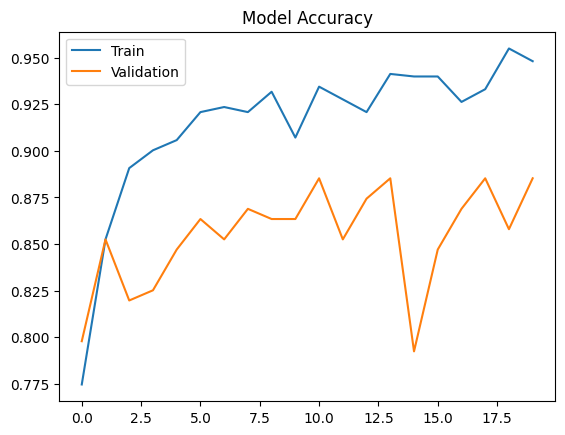

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Validation"])
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 53s 8s/step


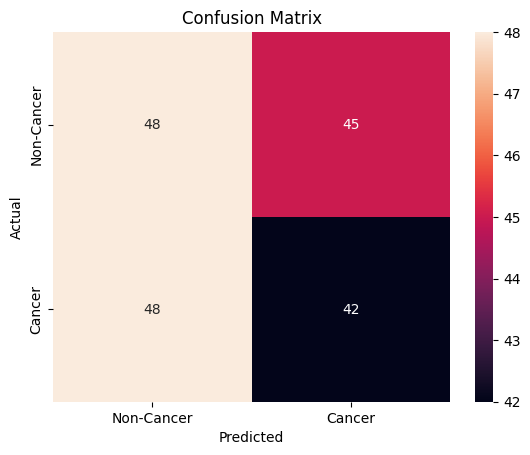

In [11]:
y_pred = model.predict(val_data)
y_pred = (y_pred > 0.5)

y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Non-Cancer','Cancer'],
            yticklabels=['Non-Cancer','Cancer'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.52      0.51        93
           1       0.48      0.47      0.47        90

    accuracy                           0.49       183
   macro avg       0.49      0.49      0.49       183
weighted avg       0.49      0.49      0.49       183

